# Práctica 2 — Campeonato de predicción

A continuación se presentan 6 escenarios distintos, 6 casos de estudio donde, dados unos datos y/o condiciones, se te pedirá que realices una estimación o predicción sobre una variable. 

Puedes utilizar los conceptos vistos en el curso para resolver alguno de los casos propuestos, pero te recomiendo que no te limites a los métodos estudiados en esta asignatura. La práctica tiene un alto componente exploratorio y de investigación, los problemas son deliberadamente abiertos y no estructurados para permitir varios enfoques. Sé creativo.

Para resolver esta práctica, puedes utilizar cualquier módulo externo, usar IAs para inspirarte, buscar problemas análogos online, etc. Todo está permitido. Eso sí, asegúrate de que justificas bien tus decisiones, en particular, los métodos o algoritmos que vas a usar para obtener cada una de las predicciones. Recuerda también citar tus fuentes.

In [ ]:
# RESPUESTAS: Predicciones/estimaciones.
# 1. 215.916
# 2. 13493.75 metros cuadrados
# 3. 2.501
# 4. 4.4
# 5. 27.251 cm, 0.272 metros
# 6. 3

------------------
## Caso 1 — Serie temporal de una variable econométrica

El siguiente archivo ( ```csv```) contiene la evolución temporal de una variable econométrica:

[Descarga estos datos](https://drive.upm.es/s/to88gulrpHxLxjB/download)

Los datos incluyen dos columnas. La primera es una fecha (tiempo), y la segunda es el valor econométrico a estudiar. Crea un modelo predictivo y predice el valor de la variable econométrica a fecha 1 de enero de 2023.

Tenemos datos desde 1924 hasta 1985, es decir, 60 años. Sin embargo el valor a predecir es de 2023, es decir de 38 años después de que se obtuviera el último dato.

Por ello se debe tener en cuenta que habrá que hacer una modelización del problema para esos 38 años de los cuales no tenemos datos y para observar hasta que punto se llega.

In [ ]:
import pandas as pd
data = pd.read_csv(r'data\forecast_data.csv', sep=',')
len(data) #744
data

,date,value
0,1924-01-01,295.000
1,1924-01-31,285.928
2,1924-03-01,299.850
3,1924-03-31,277.791
4,1924-04-30,271.728
...,...,...
739,1984-09-12,247.836
740,1984-10-12,230.645
741,1984-11-11,224.056
742,1984-12-11,208.512


In [58]:
'''vamos a construir un dataframe que acumule las medias de cada año
asi podemos representarlo en una gráfica y ver la tendencia general y poder simularla para futuros años'''
data['date'] = pd.to_datetime(data['date'])  # Convertir a datetime
data.set_index([data.date.dt.year, data.date.dt.month], inplace=True) #creamos un multiindice para acceder a los valores por el año mas fácil
data.index.names = ['año','mes']
res = data.groupby(level=0).mean() #agrupando por el año tenemos la media de cada año, 62 datos
res


,date,value
año,,
1924,1924-06-29,294.168923
1925,1925-07-09,295.039750
1926,1926-07-04,294.478000
1927,1927-06-29,309.916167
1928,1928-06-23,316.865417
...,...,...
1981,1981-06-30,205.233538
1982,1982-07-10,207.654583
1983,1983-07-05,213.447917


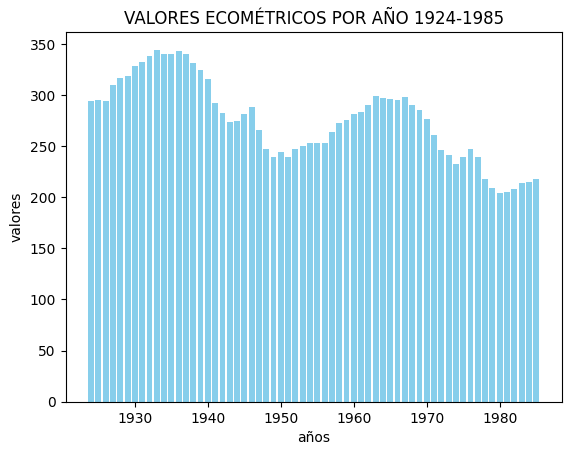

In [59]:
import matplotlib.pyplot as plt
plt.bar(res.index, res.value, color='skyblue')
plt.xlabel('años')
plt.ylabel('valores')
plt.title('VALORES ECOMÉTRICOS POR AÑO 1924-1985')
plt.show()

En esta gráfica la conclusión que podemos sacar es que después de una subida viene una bajada, después de esa bajada vuelve a subir y luego vuelve a bajar.

Dado que solamente tenemos datos temporales y los valores de cada fecha, vamos a utilizar un modelo de predicción econométrico basado en series temporales ya que los datos son mensuales y tienen un rango significativo (60 años). Nos hemos informado y hemos elegido como modelo ARIMA (Autoregressive Integrated Moving Average).
Este es un modelo de regresión que se utiliza para modelar datos que presentan patrones estacionales y tendencias a lo largo del tiempo ya que captura la autocorrelación en los datos.

https://www.hispamer.es/como-los-modelos-econometricos-ayudan-en-la-prevision-de-tendencias-economicas-y-financieras/37540#:~:text=A%20continuaci%C3%B3n%2C%20se%20presentan%20algunos%20de%20los%20modelos,Conditional%20Heteroskedasticity%29%20...%204%204.%20Modelos%20de%20Cointegraci%C3%B3n Aqui se explica de forma general los modelos de predicción en problemas económicos y financieros y su gran utilidad.

https://www.ibm.com/es-es/topics/arima-model en este link se explica como usar este modelo Arima asi como lo que significan y como se usan los parámetros que toma (p,d,q).

C:\Users\laura\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency 30D will be used.
  self._init_dates(dates, freq)
C:\Users\laura\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency 30D will be used.
  self._init_dates(dates, freq)
C:\Users\laura\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency 30D will be used.
  self._init_dates(dates, freq)


Primera predicción para el 1 de enero de 2023: 215.92579507278447


C:\Users\laura\AppData\Local\Temp\ipykernel_19188\1380544313.py:21: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  print(f'Primera predicción para el 1 de enero de 2023: {pred[-1]}')


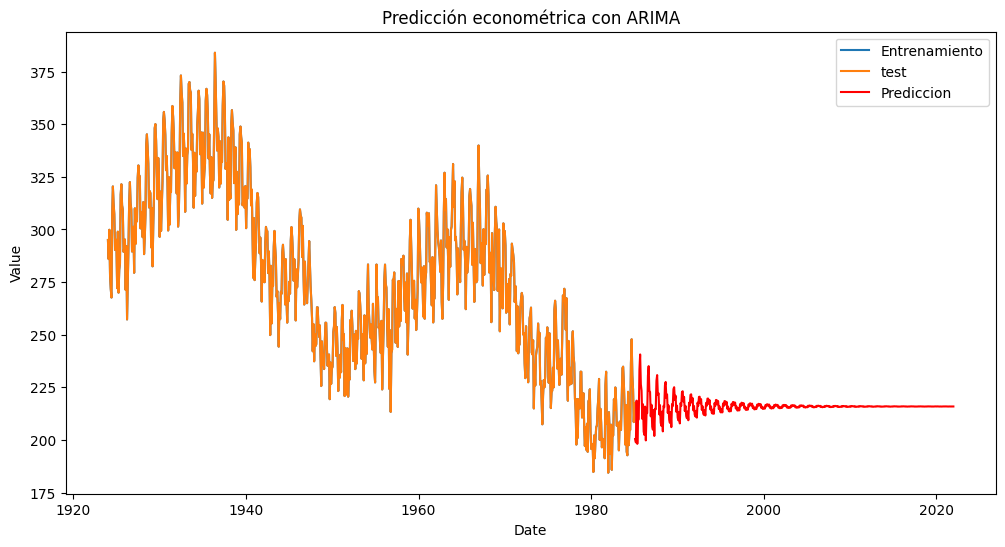

1985-02-09    200.470945
1985-03-11    198.853936
1985-04-10    218.704552
1985-05-10    198.179412
1985-06-09    209.476288
                 ...    
2021-08-29    215.917623
2021-09-28    215.926820
2021-10-28    215.914390
2021-11-27    215.955087
2021-12-27    215.925795
Freq: 30D, Name: predicted_mean, Length: 450, dtype: float64


In [ ]:
#importamos las librerias a utilizar así como pandas y numpy
from statsmodels.tsa.arima.model import ARIMA
from datetime import datetime

#cargamos los datos, no de la misma forma que antes que habiamos tomado la media de cada año para hacernos una idea de la visualización de los datos
data = pd.read_csv(r'data\forecast_data.csv')
data['date'] = pd.to_datetime(data['date'])
data.set_index('date', inplace=True)

#dividimos los datos en entrenamiento; los datos historicos que nos proporciona el dataset hasta el día anterior de la fecha predecir y en test; los datos faltantes por predecir
entrenamiento = data[:'1985-12-31']
test = data[:'1985-12-31'] #no hay datos en este rango

#Ahora necesitamos ajustar nuestro modelo para usarlo en la predicción
modelo = ARIMA(entrenamiento, order=(12,1,0)).fit() #suponemos estos parámetros de forma inicial, pero habria que hacer pruebas y ajustarlos de la mejor forma

#realiza la predicción
#primero calculamos los pasos que hay entre la última fecha de entrenamiento y la fecha a predecir su valor
pasos = (datetime(2023,1,1) -datetime(1985,12,31)).days // 30 
pred = modelo.forecast(steps=pasos) #hay que predecir todo ese espacion de tiempo
print(f'Primera predicción para el 1 de enero de 2023: {pred[-1]}')

#visualizamos la gráfica
plt.figure(figsize=(12,6))
plt.plot(entrenamiento, label='Entrenamiento')
plt.plot(test, label='test')
plt.plot(pred, label='Prediccion', color='red')
plt.title('Predicción econométrica con ARIMA')
plt.xlabel('Date')
plt.ylabel('Value')
plt.legend()
plt.show()

print(pred)

Aqui tenemos la API de la libreria de Statsmodel que nos explica los parámetros que toma el modelo que queremos usar. 
https://www.statsmodels.org/stable/generated/statsmodels.tsa.arima.model.ARIMA.html#statsmodels.tsa.arima.model.ARIMA y aquí también hemos buscado otras funciones a utilizar como por ejemplo fit() que estima los parámetros del modelo determinado o forecast() para pronósticos fuera de muestra que es lo que estima la predicción final.

Es necesario tener claro lo que indican los parametros p,d,q
d: para ello se debe determinar si los datos son estacionarios, que por la primera gráfica podemos asumir que si: este valor indica el numero de veces que se deben hacer diferencias en los datos para que estos sean estacionarios (eliminar tendencias) por ello hemos escogido d=1 que debería ser suficiente.

p: es el parametro que indica el numero de valores pasados que se utilizan para predecir el valor actual

q: indica cuántos errores pasados se utilizan para la predicción (en teoría 0)

Sin embargo para actualizar bien cual deben ser los valores p y q es necesario observar los gráficos ACF y PACF (explicado en el enlace de IBM anteriormente proporcionado). En estos gráficos si observamos un corte claro a partir de x numero de rezagos (nos referimos a rezagos en este contexto como a los valores anteriores de la serir temporal que se utilizan para predecir el valor actual).

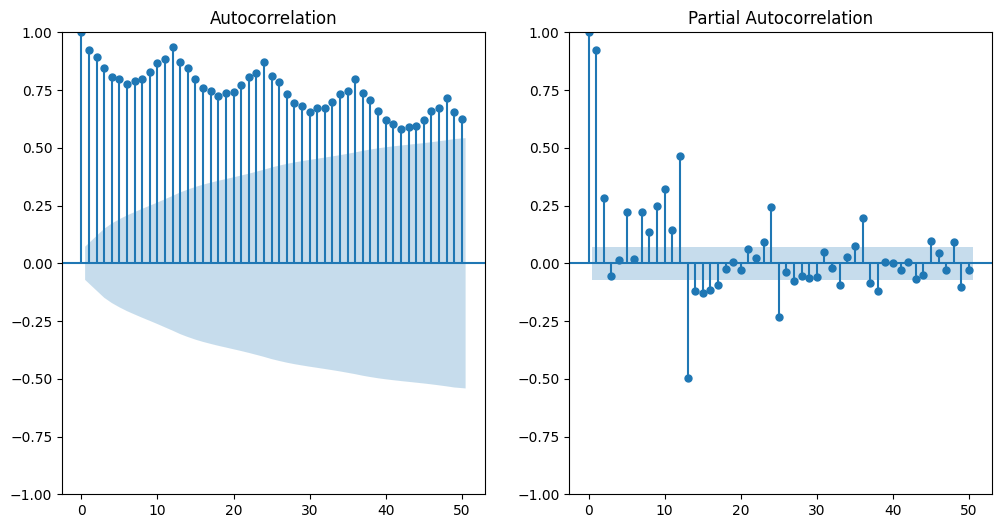

In [61]:
#vamos a observar las graficas ACF y PACF para determinar p y q correctamente
#A través de la API de statsmodels hemos encontrado los módulos a usar para visualizar las gráficas
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

#ACF -> funcion de correlacion
#PACF -> funcion de autocorelación parcial
plt.figure(figsize=(12,6))
plt.subplot(121)#dividimos la figura en dos partes para visualizar las dos graficas a la vez
plot_acf(entrenamiento, lags=50, ax=plt.gca()) #trabajamos por ejemplo con 50 rezagos
plt.subplot(122) #en la otra parte de la cuadrícual(a la derecha)
plot_pacf(entrenamiento, lags=50, ax=plt.gca()) #ax indica que se va a trabajar en la misma figura
plt.show()

Con esta observación podemos ver que en la grafica de autocorrelación no hay ningun rezago que caiga dentro de la parte sombreada y por lo tanto el valor elegido de q=0 sería una buena opción. Por otra parte en la gráfica parcial podemos observar que el primer valor que cae en la zona sombreada es la cuarta barra, pero está al límite. Vamos a ajustar el modelo con p=4 que podría ser algo más preciso.

Este proceso se podría haber realizado con auto_arima que da los valores de p,q,d pero hemos preferido hacerlo visualizándolo por nuestra cuenta.

In [62]:
modelo2 = ARIMA(entrenamiento, order=(4,1,0)).fit() #suponemos estos parámetros de forma inicial, pero habria que hacer pruebas y ajustarlos de la mejor forma

#realiza la predicción
#primero calculamos los pasos que hay entre la última fecha de entrenamiento y la fecha a predecir su valor
pasos = (datetime(2023,1,1) -entrenamiento.index[-1]).days // 30 
pred = modelo2.forecast(steps=pasos) #hay que predecir todo ese espacion de tiempo
print(f'Primera predicción para el 1 de enero de 2023: {pred[-1]}')

Primera predicción para el 1 de enero de 2023: 220.8456765388815


C:\Users\laura\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency 30D will be used.
  self._init_dates(dates, freq)
C:\Users\laura\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency 30D will be used.
  self._init_dates(dates, freq)
C:\Users\laura\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency 30D will be used.
  self._init_dates(dates, freq)
C:\Users\laura\AppData\Local\Temp\ipykernel_19188\3678051684.py:7: FutureWarning: Series.__

Ahora ya sabemos que parámetros escoger y por qué con este modelo predictivo. Sin embargo; hemos podido observar en la segunda gráfica (la de la predicción) que esta predicción no es del todo correcta ya que no se ajusta a la periocidad de los datos anteriores.
Buscando, hemos encontrado un modelo similar al anterior y que se suele relacionar con él: https://cienciadedatos.net/documentos/py51-modelos-arima-sarimax-python 
Se trata de un modelo que amplía ARIMA para manejar patrones estacionales en los datos, justo lo que nos hacía falta.

Antes de esto vamos a calcular cual podria ser la periocidad de la función: Podemos ver que cada 26 años aproximadamente se produce una curva que primero asciende y luego desciende hasta llegar a un valor de y algo más bajo que el punto de inicio de la subida. Podríamos entonces afirmar que hay una periocidad de 26 años. 

Nosotros queremos encontrar el valor econométrico del 1 de enero de 2023. 2023 estaría en el cuarto periodo si tenemos en cuenta que cada periodo son 26 años:
- (1924 - 1950)
- (1950 - 1976)
- (1976 - 2002)
- (2002 - 2028)
y según la tendencia que lleva  estaría cerca del 4º pico 

Teniendo en cuenta estos periodos vamos a utilizar ARIMAX para realizar la mejor aproximación posible. Hay que tener en cuenta que no será del todo precisa ya que no tenemos datos para esta etapa y solo podemos dar los datos anteriores.


C:\Users\laura\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency 30D will be used.
  self._init_dates(dates, freq)
C:\Users\laura\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency 30D will be used.
  self._init_dates(dates, freq)
C:\Users\laura\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
C:\Users\laura\AppData\Local\Temp\ipykernel_19188\1805765840.py:24: Futur

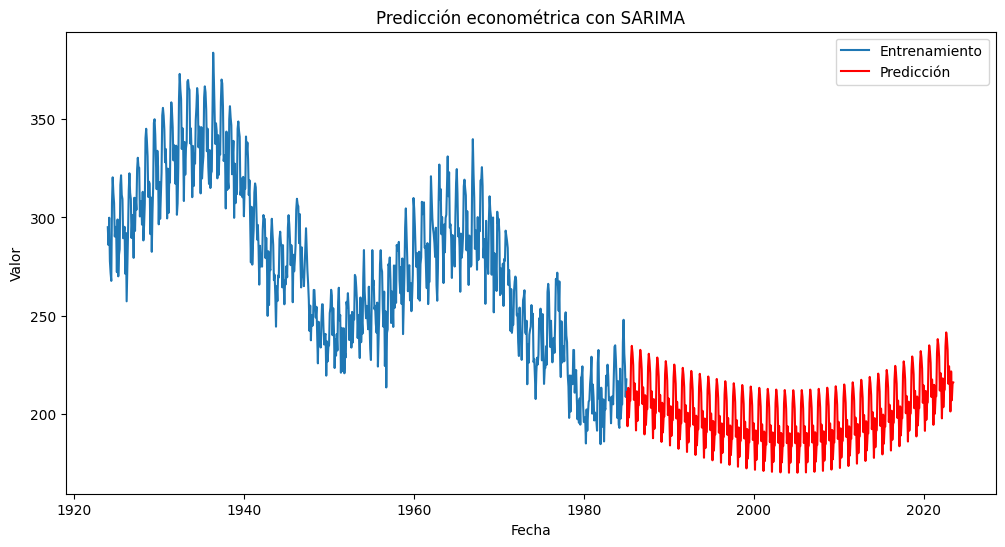

Primera predicción para el 1 de enero de 2023: 215.91650262976887


C:\Users\laura\AppData\Local\Temp\ipykernel_19188\1805765840.py:31: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  print(f'Primera predicción para el 1 de enero de 2023: {pred[-1]}')


In [63]:
from statsmodels.tsa.statespace.sarimax import SARIMAX
# A partir de los datos anteriores -> ajustamos el modelo SARIMAX
modelo = SARIMAX(entrenamiento, order=(4,1,0), seasonal_order=(0,1,1,12),
                 trend='ct').fit(disp=False)
'''usamos como order los parámetros calculados anteriormente y en seasonal
order se indican los parámetros para la patrones estacionales.
P=0, D=1, Q=1, S=12
P indica que no se tienen en cuenta terminos autorregresivos estacionales ya que
sino se iría hacia el infinito(se puede comprobar)
D indica que se tiene en cuenta un término de diferenciación estacional
Q indica que se tiene en cuenta un termino de medias moviles estacionales
S indica la periodicidad de la serie temporal, en este caso 12 meses. Se 
debería interpretar que la serie temporal tiene un patrón de 12*26 meses ya que
son 23 años de periodo pero no acaba nunca el código por lo que hemos hecho 
una aproximación.
'''

# Realizamos la predicción, los pasos siguen siendo los mismos
pred = modelo.get_forecast(steps=pasos).predicted_mean

# Visualizamos la predicción junto con los datos históricos
plt.figure(figsize=(12,6))
plt.plot(entrenamiento, label='Entrenamiento')
plt.plot(pd.date_range(start=entrenamiento.index[-1], periods=pasos, freq='M'), pred, label='Predicción', color='red')
plt.title('Predicción econométrica con SARIMA')
plt.xlabel('Fecha')
plt.ylabel('Valor')
plt.legend()
plt.show()

print(f'Primera predicción para el 1 de enero de 2023: {pred[-1]}')

Por lo tanto vamos a interpretar que el valor de la variable econométrica que se nos pide es de 215.91650262976887 para el 1 de enero de 2023

------------------
## Caso 2 — Estimación de un área

En clase habrás recibido una hoja que contiene un área. La misma hoja contiene información sobre la escala. Realiza una estimación del área encerrada. 

Para esta estimación solo disponemos de la imágen de la figura en cuestión. Investigando hemos observado que la forma más óptima para calcular este área será a partir de la librería OpenCV y a partir de la imagen buscar los contornos con esta harramienta. 
Debemos informarnos sobre como funciona esta librería.
https://docs.opencv.org/3.4/d1/dfb/intro.html (aquí se centran en C++ pero explican conceptos importantes)
Es una librería que tiene cientos de algoritmos de visión artificial y es un paquete con múltiples recursos para el problema que queremos abordar.

Entre otras características OpenCV nos proporciona en distintos módulos: procesamiento de imágenes, de vídeo, detección de objetos,...

Como biblioteca de visión artificial, OpenCV se ocupa mucho de los píxeles de imagen que se codifican en 8 o 16 bits, por lo que tienen un rango de valores limitado. Sin embargo; ciertas operaciones en imágenes pueden producir valores fuera del rango disponible. Para resolver este problema, en una imagen de 8 bits, se busca el valor más cercano dentro del intervalo de 0..255:

(Ahora observaremos que los valores de los pixeles se mantienen en este rango)


También hemos investigado sobre las redes neuronales convolucionales CNN (sirven para la detección, clasificación y segmentación de imágenes) que también podían dar una solución a este problema: hemos concluído con que iba a ser muy complicado utilizarlas y que la solución podría ser igual de óptima que la del OpenCV por lo tanto la hemos descartado.

In [ ]:
import cv2 as cv
#cargamos la foto del area
imagen = cv.imread(r'data\lago_area.jpg')
#podemos observar que nos devuelve un array de numpy con los valores de los pixeles de la imagen 
imagen

array([[[255, 255, 255],
        [255, 255, 255],
        [255, 255, 255],
        ...,
        [255, 255, 255],
        [255, 255, 255],
        [255, 255, 255]],

       [[255, 255, 255],
        [255, 255, 255],
        [255, 255, 255],
        ...,
        [255, 255, 255],
        [255, 255, 255],
        [255, 255, 255]],

       [[255, 255, 255],
        [255, 255, 255],
        [255, 255, 255],
        ...,
        [255, 255, 255],
        [255, 255, 255],
        [255, 255, 255]],

       ...,

       [[255, 255, 255],
        [255, 255, 255],
        [255, 255, 255],
        ...,
        [255, 255, 255],
        [255, 255, 255],
        [255, 255, 255]],

       [[255, 255, 255],
        [255, 255, 255],
        [255, 255, 255],
        ...,
        [255, 255, 255],
        [255, 255, 255],
        [255, 255, 255]],

       [[255, 255, 255],
        [255, 255, 255],
        [255, 255, 255],
        ...,
        [255, 255, 255],
        [255, 255, 255],
        [255, 255, 255]]

El proceso de encontrar los contornos se aplica sobre imágenes binarias; es decir, que solo tengan 2 valores posibles sus píxeles (representado con los colores blanco y negro). Para ello debemos hacer una escala para determinar que está dentro del 'lago' y que está fuera.
https://omes-va.com/contornos/ Aquí se explica la forma de recuperar contornos y los métodos que hay. Nosotros no deberíamos de tener problema ya que la imagen es en blanco y negro y están diferenciadas las dos partes. 
Como podemos observar en las imágenes de la web anterior se captan las imagénes con el fondo negro y el objeto en blanco. En nuestra imagen está al revés asique debemos invertirlo.

http://opencv.jp/opencv-2.2_org/py/imgproc_miscellaneous_image_transformations.html En esta página es donde hemos encontrado todas las funciones necesarias para abordar los siguientes pasos: 

In [65]:
import numpy as np
#convertimos a escala de grises para facilitar encontrar los contornos
gris = cv.cvtColor(imagen, cv.COLOR_BGR2GRAY) #valores de los pixeles

#queremos convertir la imagen en una imagen binaria tal que el objeto sea negro y el fondo blanco
_, umbral = cv.threshold(gris,128,255,cv.THRESH_BINARY)

#vamos a limpiar la imagen usando un filtro que reduce el ruido y que omite los pequeños contornos o los cierra
umbral = cv.GaussianBlur(umbral, (5, 5), 0)
#aplicar un umbral para cerrar pequeños huecos en los contornos y que capte contornos completos y no la unión de pequeños contornos
kernel = np.ones((5, 5), np.uint8)
umbral = cv.dilate(umbral, kernel, iterations=2)
umbral = cv.erode(umbral, kernel, iterations=2)

#encontramos los contornos a partir de la imagen binaria
contornos, jerarquia = cv.findContours(umbral, cv.RETR_TREE, cv.CHAIN_APPROX_SIMPLE)
'''hemos escogido RETR_TREE porque queremos recuperar el contorno interno y este 
método aparte del contorno nos ofrece una jerarquía de estos contornos.
Vamos a probar con CHAIN_APPROX_NONE porque almacena todos los puntos del contorno
y puede que sea más preciso que CHAIN_APPROX_SIMPLE aunque este ahorre más memoria.

Cambiándolo hemos comprobado que no varía el valor por lo que vamos a utilizar 
CHAIN_APPROX_SIMPLE que ocupa menos memoria.

Cogiendo todos los contornos hemos observado que cuando se imprime, también se 
imprime el recuadro de la imagen, cuyo contorno y area no se necesita.
Para corregir esto vamos a coger todos los contornos menos este que investigando
con la API en RETR_TREE hemos visto que es posible.
'''
contornos_internos = [contornos[i] for i in range(len(contornos)) if jerarquia[0][i][3] != -1]
#cogemos solamente los contornos internos. Ya que RETR_TREE nos permite manejar una jerarquía entre
#todos los contornos, buscamos a todos aquellos que tengan un contorno padre y no sean el contorno padre.
#osea que en la posicion 3 de la jerarquía no tenga un -1 (significa que es padre)
#La jerarquía es una lista de listas con la estructura:

print(jerarquia)
'''
aquí se puede observar una lista de listas, nos quedaríamos con todos menos con el primero porque el 
primero al tener un -1 en la última posición significa que ese contorno no tiene un contorno padre
'''
# 1ª -> siguiente contorno
# 2º -> contorno previo
# 3º -> primer hijo
# 4º -> padre de algun contorno

[[[-1 -1  1 -1]
  [ 2 -1 -1  0]
  [ 3  1 -1  0]
  [ 4  2 -1  0]
  [ 5  3 -1  0]
  [ 6  4 -1  0]
  [ 7  5 -1  0]
  [ 8  6 -1  0]
  [ 9  7 -1  0]
  [10  8 -1  0]
  [-1  9 -1  0]]]


'\naquí se puede observar una lista de listas, nos quedaríamos con todos menos con el primero porque el \nprimero al tener un -1 en la última posición significa que ese contorno no tiene un contorno padre\n'

Vamos a pasar de píxeles a centímetros al cuadrado y a partir de ahí utilizaremos la escala que se nos proporciona (3cm = 50m)
Para ello debemos conocer la resolución de la imagen que hemos utilizado. Accedemos a esta información observando los detalles de la imagen:
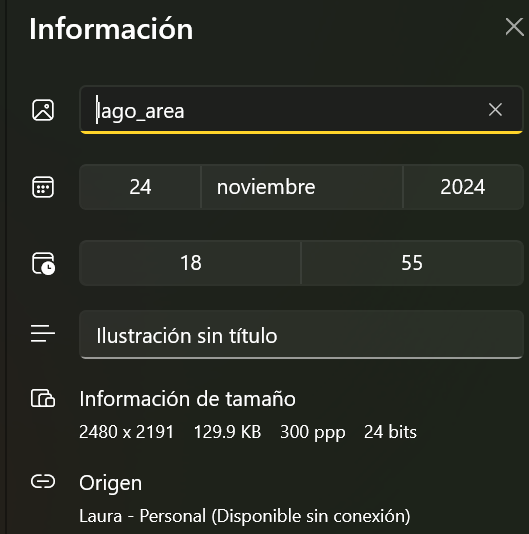

RESOLUCIÓN : 300 ppp 


ppp = píxeles por pulgada 

ppcm = píxeles por centímetro

La conversión de ppi a cm^2 es muy sencilla:

ppcm = ppp / 2,54

area en cm^2 = area_pixels / ppcm^2

In [66]:
if contornos_internos: 
    area_pixels = sum(cv.contourArea(contorno) for contorno in contornos_internos)
    ppp = 300 #datos 
    ppcm = ppp/2.54
    area_cm2 = area_pixels/ppcm**2
    print(f'area en cm al cuadrado: {area_cm2}')
    #hacemos el paso a metros al cuadrado con la escala 3 centimetros son 50 metros
    cm2 = (50/3)**2
    area_metros2 = area_cm2*cm2
    print(f'area en metros al cuadrado: {area_metros2}; es decir {area_metros2/10000} hectáreas')

area en cm al cuadrado: 48.57750141111111
area en metros al cuadrado: 13493.75039197531; es decir 1.349375039197531 hectáreas


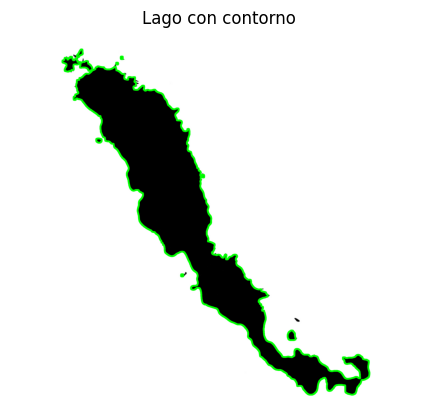

In [67]:
#vamos a visualizar el lago con su contorno:
import matplotlib.pyplot as plt
cv.drawContours(imagen, contornos_internos, -1, (0,255,0), 10) #estos valores son para el color y el grosor de la línea, el -1 indica que se dibujen todos los contornos encontrados
plt.imshow(cv.cvtColor(imagen,cv.COLOR_BGR2RGB))
plt.title('Lago con contorno')
plt.axis('off')
plt.show()


En conclusión hemos observado que cogiendo el contorno de la manera más precisa posible de esta figura y aplicando la escala se nos da nos quedamoms con que el area de la figura sería: 13493.75039197531 metros cuadrados

------------------
## Caso 3 — Estimación funcional

Observa los siguientes pares de valores $x$, $y$. Predice cuál será el valor asociado a un $x=-0.16$

<center>

|      $x$      |     $y$      |
|-------------|------------|
|  0.808      | 1.081      |
|  0.087      | 3.166      |
| -0.359      | 1.801      |
| -0.281      | 1.949      |
|  0.257      | 2.024      |
|  0.279      | 1.979      |
|  0.604      | 1.275      |
| -0.303      | 1.880      |
|  0.722      | 1.126      |
| -0.760      | 1.130      |
|  0.407      | 1.627      |
|  0.215      | 2.247      |
| -0.912      | 1.081      |
|  0.013      | 5.006      |
| -0.972      | 1.032      |


</center>


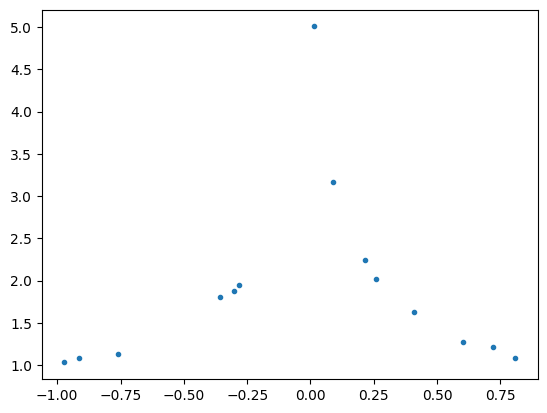

In [68]:
#creamos dos arrays con los valores x_y ordenados
#lo mejor para interpolar este caso aunque aparentemente parezca algo que no se haría es usar el polinomio de lagrange\newton ya que nos interesesa tener un polinimio de grado 
# alto, que son los que mejor interpolan puntos centrados, no son buenas aproximaciones para puntos exteriores pero como nos piden la aproximaión en precticamente la mitad del 
# dominio, procederemos a usar este método.
x = np.array([-0.972,-0.912,-0.760,-0.359,-0.303,-0.281,0.013,0.087,0.215,0.257,0.407,0.604,0.722,0.808])
y = np.array([1.032,1.081,1.130,1.801,1.880,1.949,5.006,3.166,2.247,2.024,1.627,1.275,1.216,1.081])
plt.plot(x,y,'.')

In [69]:
#usamos el método de newton para predecir el comportamiento de la función ya que computacionalmete es mas eficiente, va a dar serios comportamientos erróneos
def newton_method(x_data, y_data, x_val):
    """
    Evalúa en 'x_val' el polinomio interpolante p(x) que pasa por los datos 
    especificados en 'x_data' e 'y_data' usando el método de interpolación de 
    Newton.
    """

    def compute_newton_coefficients(x_data, y_data):
        m = len(x_data)
        coefficients = y_data.copy()
        for k in range(1, m):
            for i in range(m - 1, k - 1, -1):
                coefficients[i] = (coefficients[i] - coefficients[i - 1]) / (x_data[i] - x_data[i - k])
        return coefficients

    n = len(x_data) - 1 
    coefficients = compute_newton_coefficients(x_data, y_data)  # Compute coefficients each time
    p = coefficients[n]
    for k in range(n - 1, -1, -1):
        coefficients = compute_newton_coefficients(x_data, y_data)  # Compute coefficients again in each iteration
        p = coefficients[k] + (x_val - x_data[k]) * p
        
    return p

In [70]:
# creamos una serie de valores para ver si nuestro método de aproximación es coherente
x = np.array([-0.972,-0.912,-0.760,-0.359,-0.303,-0.281,0.013,0.087,0.215,0.257,0.407,0.604,0.722,0.808])
y = np.array([1.032,1.081,1.130,1.801,1.880,1.949,5.006,3.166,2.247,2.024,1.627,1.275,1.216,1.081])
aproximacion = newton_method(x,y,-0.16)
print(aproximacion)
x_aprox = np.arange(x.min(),x.max(),0.001).round(3)
y_aprox = [newton_method(x,y,i) for i in x_aprox]
junte = zip(x_aprox,y_aprox)
for x,y in junte:
    print(f'{x}: {y}')

5.078982014514825
-0.972: 1.032
-0.971: -3.6124232898848074
-0.97: -7.968391918479554
-0.969: -12.045011159734532
-0.968: -15.851191428206398
-0.967: -19.39565141474085
-0.966: -22.686921182529595
-0.965: -25.733345223941047
-0.964: -28.54308547852135
-0.963: -31.124124312558475
-0.962: -33.484267460599966
-0.961: -35.63114692931052
-0.96: -37.5722238640537
-0.959: -39.314791378577794
-0.958: -40.86597734818406
-0.957: -42.23274716675091
-0.956: -43.42190646798622
-0.955: -44.440103811275335
-0.954: -45.29383333249113
-0.953: -45.989437360127155
-0.952: -46.53310899711431
-0.951: -46.93089466867694
-0.95: -47.18869663658211
-0.949: -47.312275480131916
-0.948: -47.30725254424769
-0.947: -47.17911235498943
-0.946: -46.93320500285378
-0.945: -46.574748494188384
-0.944: -46.10883107105971
-0.943: -45.540413499907245
-0.942: -44.874331329315325
-0.941: -44.11529711722952
-0.94: -43.26790262794361
-0.939: -42.33662099917913
-0.938: -41.32580887957714
-0.937: -40.23970853691931
-0.936: -39.08

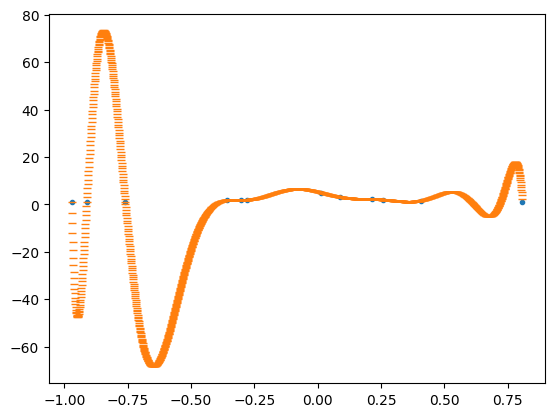

In [71]:
#observamos que es erróneo ya que oscila demasiado entre algunos nodos
x = np.array([-0.972,-0.912,-0.760,-0.359,-0.303,-0.281,0.013,0.087,0.215,0.257,0.407,0.604,0.722,0.808])
y = np.array([1.032,1.081,1.130,1.801,1.880,1.949,5.006,3.166,2.247,2.024,1.627,1.275,1.216,1.081])
plt.plot(x,y,'.',)
plt.plot(x_aprox,y_aprox,'_',)

In [72]:
#función para realizar ajustes por polinomios
def matriz_a(x,y,m):
    matriz = np.zeros((m+1,m+1))
    for i in range(m+1):
        for j in range(m+1):
            suma = 0.0
            for k in range(len(x)):
                suma += x[k]**(j+i)
            matriz[i][j] = suma
    return matriz

def matriz_b(x,y,m):
    matriz = np.zeros((1,m+1))
    for k in range(m+1):
        suma = 0.0
        for i in range(len(x)):
            suma+=(x[i]**k)*y[i]
        matriz[0][k] = suma
    return matriz

def poly_fit(x_data,y_data,m,x_val):
    A = matriz_a(x_data,y_data,m)
    b = matriz_b(x_data,y_data,m).T
    a = np.linalg.solve(A,b)
    resul = 0.0
    for i in range(len(a)):
        resul += a[i]*x_val**i

    return resul[0]
    

Resultado de splin cúbico de scipy es 3.8477277831113676


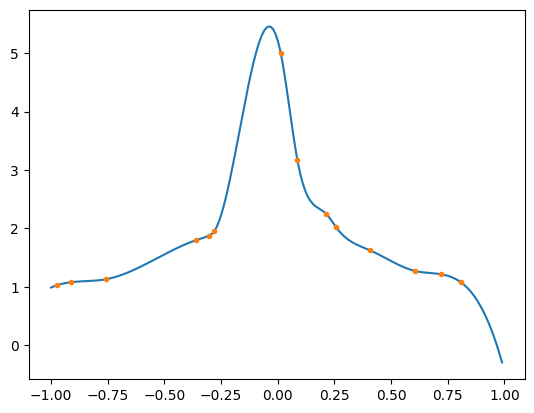

In [73]:
#intento de aproximación por splines
from scipy.interpolate import CubicSpline
from scipy.optimize import curve_fit
x = np.array([-0.972,-0.912,-0.760,-0.359,-0.303,-0.281,0.013,0.087,0.215,0.257,0.407,0.604,0.722,0.808])
y = np.array([1.032,1.081,1.130,1.801,1.880,1.949,5.006,3.166,2.247,2.024,1.627,1.275,1.216,1.081])
x0 = -0.16
spline = CubicSpline(x,y,bc_type='not-a-knot')
x_todo = np.arange(-1,1,0.01).round(3)
y_todo = np.array([spline(x) for x in x_todo])

print(f'Resultado de splin cúbico de scipy es {spline(x0)}')
plt.plot(x_todo,y_todo)
plt.plot(x,y,'.')

y en x:-0.16 = 2.437997247857143


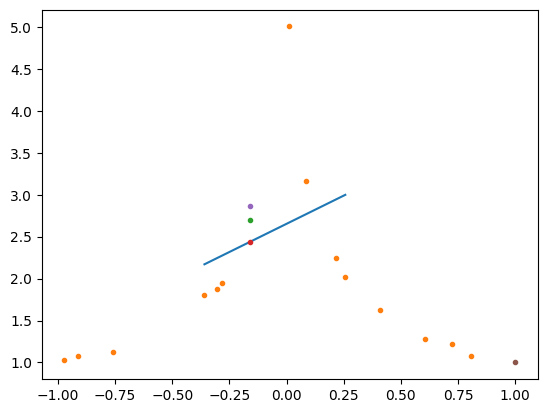

In [74]:
#diferentes intentos de acercarnos al valor de la función,curiosamente ajustar los puntos centrales por un polinomio lineal, nos da un valor en -0.16 muy razonable de 2.43799
x = np.array([-0.972,-0.912,-0.760,-0.359,-0.303,-0.281,0.013,0.087,0.215,0.257,0.407,0.604,0.722,0.808])
y = np.array([1.032,1.081,1.130,1.801,1.880,1.949,5.006,3.166,2.247,2.024,1.627,1.275,1.216,1.081])
grado_p = 1
x_nueva = np.array([-0.359,-0.303,-0.281,0.013,0.087,0.215,0.257])
y_nueva = np.array([1.801,1.880,1.949,5.006,3.166,2.247,2.024])
x_full = np.arange(-1,1,0.1).round(3)
y_ajus = [poly_fit(x_nueva,y_nueva,grado_p,i) for i in x_nueva]
y_ajusho = [2.5 for i in x]
y_full_ajus = [poly_fit(x_nueva,y_nueva,grado_p,i) for i in x]
print(f'y en x:-0.16 = {poly_fit(x_nueva,y_nueva,grado_p,-0.16)}')
#plt.plot(x_nueva,y_ajus,'.',color='red')
plt.plot(x_nueva,y_ajus,'-')
plt.plot(x,y,'.')
plt.plot(-0.16,2.703,'.')
plt.plot(-0.16,2.43799,'.')
plt.plot(-0.16,2.868,'.')
plt.plot(1,1,'.')

In [75]:
# utilizado para medir distintos aproaches al resultado
def coeficiente_determinacion(y_data:np.array,y_aprox:np.array):
    rss = 0
    tss = 0
    media_v_dependiente = np.mean(y_data)
    for i in range(len(y_data)):
        rss += (y_data[i] -y_aprox[i])**2
        tss += (y_data[i] -media_v_dependiente )**2
    return 1 - rss/tss
coeficiente_determinacion(y_nueva,y_ajus)

np.float64(0.0887852501141786)

## Hipótesis final:

Función simetrica, por lo que vamos duplicar valores para obtener un mayor número de datos y que nuestras interpolaciones/ajustes tengan mayor precisión

In [76]:
x_s = [-0.972,-0.912,-0.760,-0.359,-0.303,-0.281,-0.013,-0.087,-0.215,-0.257,-0.407,-0.604,-0.722,-0.808,0.013,0.087,0.215,0.257,0.407,0.604,0.722,0.808,0.972,0.912,0.760,0.359,0.303,0.281]
y_s = [1.032,1.081,1.130,1.801,1.880,1.949,5.006,3.166,2.247,2.024,1.627,1.275,1.216,1.081,5.006,3.166,2.247,2.024,1.627,1.275,1.216,1.081,1.032,1.081,1.130,1.801,1.880,1.949]
pares = []
for xs, ys in zip(x_s,y_s):
    pares.append((xs,ys))

In [77]:
pares.sort(key=lambda x:x[0])

In [78]:
x_s = [x[0] for x in pares]
y_s = [x[1] for x in pares]

Según la teoría, el grado óptimo para un polinimio que hace un ajuste se encuentra entre 2 y 6.
Esto se debe a que un grado alto genera grandes oscilaciones (ruido).
Lo que proponemos es que mediante una primera interpolación por splines cúbicos, hacernos una idea del valor de la función en x=-0.16 y tener una referencia para los ajustes posteriores.

Una vez hecho esto, para evitar que las oscilaciones producidas por un polinomio de grado 3 sean muy grandes al estar tanto el nodo previo a -0.16 como el posterior ''alejados'', vamos a hacer una media de valores de diferentes ajustes ''razonables'' y 
esta será nuestra aproximación final.

ajuste polinomial de grado 18 = 2.4515976254277074
ajuste polinomial de grado 2 = 2.5455694832720988
ajuste polinomial de grado 16 = 2.639502839129365
la aproximacion por splines cubicos es de: 2.368962214998713


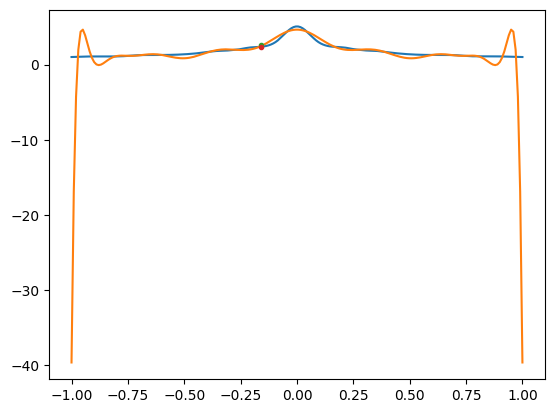

In [79]:
grado_p = 18
coefficients = np.polyfit(x_s, y_s, grado_p)
polynomial = np.poly1d(coefficients)
spline = CubicSpline(x_s,y_s,bc_type='natural')
print(f'ajuste polinomial de grado {grado_p} = {poly_fit(x_s,y_s,grado_p,-0.16)}')
print(f'ajuste polinomial de grado 2 = {poly_fit(x_s,y_s,2,-0.16)}')
print(f'ajuste polinomial de grado 16 = {poly_fit(x_s,y_s,16,-0.16)}')
print(f'la aproximacion por splines cubicos es de: {spline(-0.16)}')
x_ful = np.linspace(1,-1,200)
y_fulspline = [spline(x) for x in x_ful]
y_fulpoly = [poly_fit(x_s,y_s,grado_p,i) for i in x_ful]
y_fulpolynp = [polynomial(i) for i in x_ful]
plt.plot(x_ful,y_fulspline,'-')
#plt.plot(x_ful,y_fulpoly,'-')
plt.plot(x_ful,y_fulpolynp,'-')
plt.plot(-0.16,2.545,'.')
plt.plot(-0.16,2.368,'.')

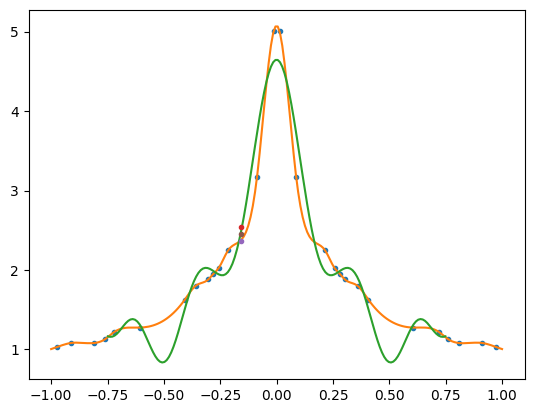

In [80]:
plt.plot(x_s,y_s,'.')
plt.plot(x_ful,y_fulspline,'-')
plt.plot(x_ful[25:-25],y_fulpoly[25:-25],'-')
plt.plot(-0.16,2.545,'.')
plt.plot(-0.16,2.368,'.')
plt.plot(-0.16,2.451,'.')

In [81]:
# media final
arr = np.array([2.45152358194765,2.5455694832720988,2.639502839129365,2.368962214998713])
arr.mean()

np.float64(2.501389529836957)

## Nuestra predicción final para x= -016 es: 2.501

------------------
## Caso 4 — Subasta de 5€

El día 28 de noviembre, en clase subastaré un billete de 5€. La subasta tiene unas normas un poco especiales:
 - El objetivo es pujar para ganar un billete de 5€.
 - El ganador recibirá 5€, pero a diferencia de las subastas "normales", **tanto el ganador como el subcampeón deberán pagar la cantidad de sus ofertas**.
 - Las ofertas deben aumentarse en incrementos mínimos de 20 céntimos.
 - No hay límites en la cantidad de rondas de pujas.

Ejemplo: imagina que el grupo A comienza la puja por 20 céntimos. El grupo B sube la puja a 40 céntimos. El grupo A vuelve a subir la puja a 80 céntimos. Ahora el grupo C sube la puja a 1€ y 40 céntimos. No hay más pujas: el grupo B paga 80 céntimos. El grupo C paga 1€ y 40 céntimos, y recibe el billete de 5€.

Si no pujas, no pierdes nada, y puedes ganar 5€ por una pequeña cantidad. Esto quiere decir que el [valor esperado](https://en.wikipedia.org/wiki/Expected_value) del juego es positivo, lo que significa que es rentable jugar.

En el contexto de esta práctica, tu objetivo será **predecir la suma de las dos ofertas más altas** de la subasta.

### Lo esperado sería:

In [82]:
# Hipótesis: La diferencia entre el beneficio y el riesgo ha de ser positiva para que una persona decida pujar
def puja(importe,rival,valor):
    beneficio = valor - importe
    if beneficio - importe > 0.4:
        importe =  rival + 0.2
        return importe
    else:
        return None

def campeonato(valor):
    j1 = 0
    j2 = 0
    Error = False
    while not Error:
        if j1 > j2:
            j = j2
            j2 = puja(j2,j1,valor)
            if j2 == None:
                Error = True
                j2 = j
                continue
        else:
            j = j1
            j1 = puja(j1,j2,valor)
            if j1 == None:
                Error = True
                j1 = j
                continue
    return print(f'{j1=}, {j2=} , suma_total = {j1+j2}')

campeonato(5)

j1=2.6, j2=2.4 , suma_total = 5.0


No sabemos como acabará la puja al final y pero suponemos que la suma final será de 4.4 euros

------------------
## Caso 5 — Experimento físico

En clase se describirá un experimento físico que se llevará a cabo el día 28 de noviembre. Presta atención a los datos dados y a la variable a predecir.


El experimento físico explicado consiste en tirar una canica desde arriba de una mesa. Encima de esta mesa hay un libro sobre el cual está apoyado en su borde un tubo de cartón. Ese tubo de cartón tiene una cierta inclinación ya que una parte se apoya sobre el borde del libro y la parte opuesta sobre el filo de la mesa. 

El experimento consiste en que la canica se tire por ese tubo inclinado y entonces caiga al suelo. La incognita por lo tanto es: ¿Cuál será la distancia entre la mesa y la posición donde caiga la canica?

Tenemos estos datos:

- grosor del libro = 3.2 cm
- largo del tubo = 66 cm
- grosor del tubo = 0.4 cm (puede que no lo utilicemos)
- alto de la mesa = 76.7 cm 

Aqui tenemos una imagen que modela la posición de los objetos:
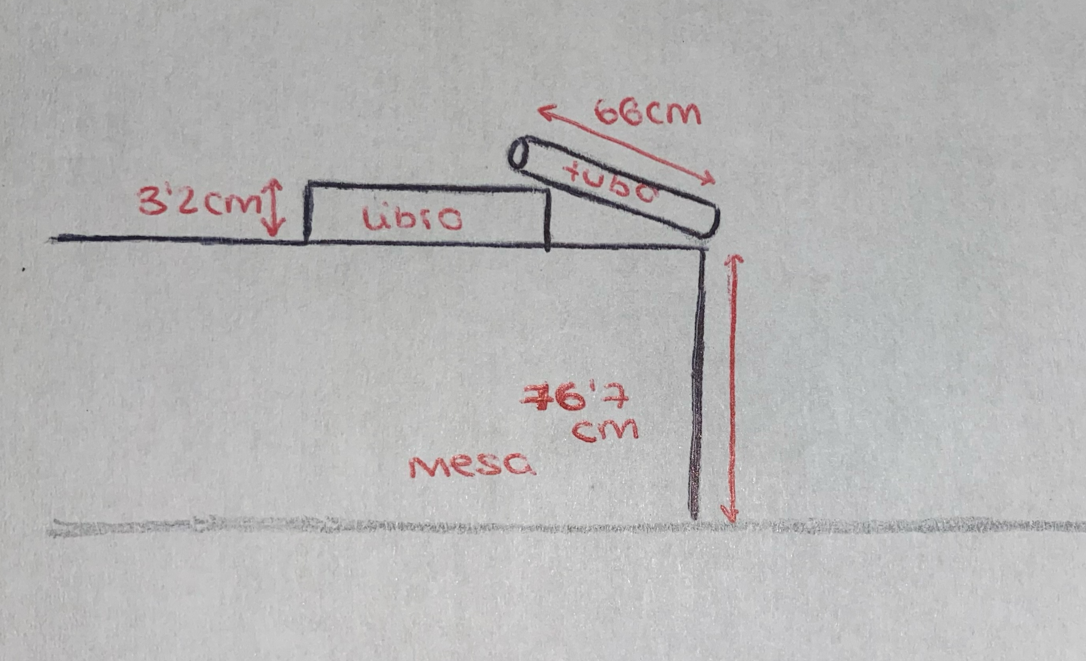

Vamos a suponer que no hay ni resistencia por parte del aire ni fricción por parte del tubo, la canica simplemente rueda por el tubo y cae en el suelo a una distancia x.

En este experimento por lo tanto tenemos dos movimientos destacables:
- movimiento uniformemente acelerado por el tubo inclinado, es decir el recorrido de la canica desde que entra al tubo hasta que sale.
- tiro parabólico desde que sale del tubo hasta que cae en el suelo. No sería caída libre porque sale con una velocidad hacia delante de ese tubo. La componente horizontal de la velocidad está dirigida hacia delante y hacia abajo desde el punto de salida del tubo; es decir, la velocidad ya tiene un ángulo descendente en el momento en el que la canica sale.

Para el primer movimiento hemos adoptado las fórmulas y explicaciones (con y sin fricción) de: https://espanol.libretexts.org/Fisica/Libro%3A_F%C3%ADsica_Universitaria_I_-_Mec%C3%A1nica_Cl%C3%A1sica_(Gea-Banacloche)/08%3A_Movimiento_en_Dos_Dimensiones/8.03%3A_Planos_Inclinados 


In [83]:
h_mesa = 0.767 #todo en metros
h_tubo = 0.66
h_libro = 0.032
angulo = -np.degrees(np.arcsin(h_libro/h_tubo)) #negativo(observar dibujo)

#primer movimiento de la canica -> movimiento por el plano inclinado
g = 9.81 #pasada la gravedad a m/s2
'''
aceleración en el plano inclinado: si el objeto se desliza sin fricción será la fuerza gravitatoria
El tiempo que tarda en bajar por el tubo, suponemos que la altura del tubo es evidentemente
el espacio recorrido por la canica -> aplicamos las formulas del MRUA
x = x0 + v0*t + 1/2*a*t^2
h_tubo = 0 + 0 + 1/2*a*t^2 entonces sacamos t

tambien hay una forma de sacar la velocidad sin tener que sacar el tiempo:
v_final^2 = v_inicial^2 + 2*a*distancia recorrida
usamos esta segunda:
'''

v_salida = (2*g*h_libro)**0.5

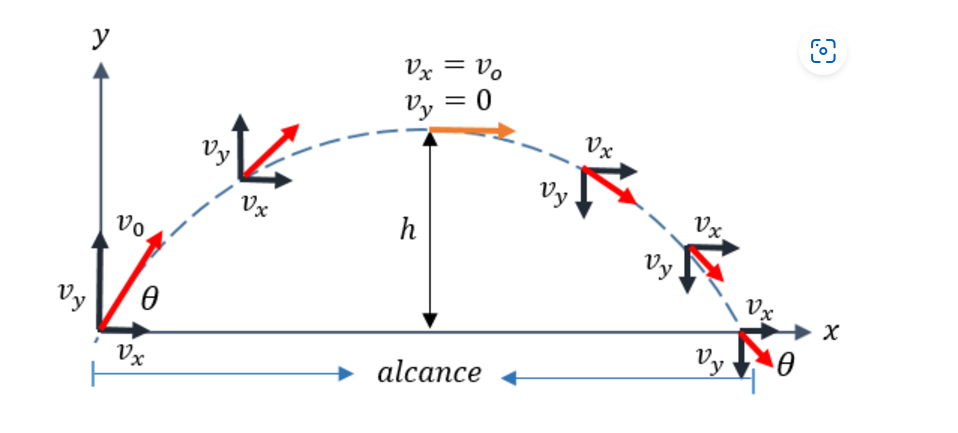
Aquí podemos observar que hay que tener en cuenta en el movimiento parabólico en la velocidad tanto las componentes x como las y. En nuestro caso nos encontramos en la parte del centro hacia la derecha. 

El momento inicial no sería la imagen del centro porque la velocidad ya sale con una cierta componente v0y y otra componente v0x por el movimiento anterior. 

Las fórmulas serían usando trigonometría:

v0x = v0 * cos(angulo)

v0y = v0 * sen(angulo)

In [84]:
#segundo movimiento de la canica -> tiro parabólico
'''
componentes de la velocidad de salida para el tiro parabólico, segundo movimiento.
Este tiene una velocidad inicial en el plano de x y otra en el plano de y. Una haría que la canica se 
desplazara hacia adelante y la otra hacia abajo
'''
v0x = v_salida * np.cos(angulo)
v0y = -v_salida * np.sin(angulo) #lo desplazaría hacia abajo por eso es negativo

'''
tiempo de caída desde que sale del tubo, para ello usamos la fórmula del tiro parabólico para la 
componente y:
y = y0 + v0y*t + 1/2*a*t^2 siendo y = 0 porque la canica acaba en el suelo,
a=g debido a la caída libre, y0 = h_mesa
Esta función es una ecuación de segundo grado que se puede resolver despejando
la variable t tal que:
'''
t_caida = (v0y - np.sqrt(v0y**2 + 2*g*h_mesa))/(g)
#escogemos el valor negativo de la raíz porque también da un valor favorable para
#el tiempo de caída y una vez sustituido en la ecuación para calcular la distancia
#tambien nos da un valor positivo, si escogieramos el positivo nos daría una 
#distancia negativa por lo que lo descartamos

'''
por último vamos a calcular la distancia recorrida por la canica en el plano x en el tiempo que tarda
en caer al suelo desde que sale del tubo. Para ello usamos la formula de la velocidad del MRU
'''
dist = v0x*t_caida 

print(f'la canica caerá a {dist} m de la mesa')

la canica caerá a 0.272511310170624 m de la mesa


------------------
## Caso 6 — Predicción deportiva

El fin de semana del 29 Nov - 1 Dic se juega el partido O. Lyon vs Niza (*Ligue 1*, Francia). Tu objetivo es predecir el **número de corners que sacará el Niza** en ese partido. Tienes a tu disposición muchos datos históricos, por ejemplo en [esta web](https://www.football-data.co.uk/data.php).

In [85]:
#sacamos tanto información del niza como del O.L, para ello vamos a contabilizar estadísticas desde la llegada
# del entrenador actual de alguno de los equipos.
#Niza es visitante, el Lyon juega en casa
# Explotaremos estos datos recientes, pero no usaremos datos históricos ya que pueden ser poco relevantes.

entrada_entrendor_niza = '01/07/2024'

In [ ]:
datos_2024 = pd.read_csv(r'data\F1.csv',sep=',')
nivel_equipos = datos_2024

In [87]:
# media de corneres provocados para obtener un contexto
datos_2024_en_casa_niza = datos_2024.where(datos_2024.HomeTeam == 'Nice').dropna()
datos_2024_fuera_casa_niza = datos_2024.where(datos_2024.AwayTeam == 'Nice').dropna()
media_niza_2024_away = datos_2024_fuera_casa_niza['AC'].mean()
media_niza_2024_casa = datos_2024_en_casa_niza['HC'].mean()
print(f'{media_niza_2024_casa=}')
print(f'{media_niza_2024_away=}')

media_niza_2024_casa=np.float64(4.8)
media_niza_2024_away=np.float64(4.666666666666667)


In [88]:
#datos niza casa buscar posibles correlaciones de datos
datos_2024_en_casa_niza = datos_2024_en_casa_niza[['Date','HomeTeam','AwayTeam','FTR','HC','HS','FTHG']]
datos_2024_en_casa_niza.set_index('Date',inplace=True)
datos_2024_en_casa_niza.index = pd.to_datetime(datos_2024_en_casa_niza.index,dayfirst=True)
datos_2024_en_casa_niza.sort_index(inplace=True)
datos_2024_en_casa_niza['tiros/goles'] = (datos_2024_en_casa_niza.FTHG /datos_2024_en_casa_niza.HS).round(3)*100
datos_2024_en_casa_niza['tiros/corner'] = (datos_2024_en_casa_niza.HS /datos_2024_en_casa_niza.HC).round(3)
datos_2024_en_casa_niza

,HomeTeam,AwayTeam,FTR,HC,HS,FTHG,tiros/goles,tiros/corner
Date,,,,,,,,
2024-09-20,Nice,St Etienne,H,3.0,18.0,8.0,44.4,6.000
2024-10-06,Nice,Paris SG,D,5.0,9.0,1.0,11.1,1.800
2024-10-27,Nice,Monaco,H,6.0,17.0,2.0,11.8,2.833
2024-11-10,Nice,Lille,D,6.0,17.0,2.0,11.8,2.833
2024-11-24,Nice,Strasbourg,H,4.0,15.0,2.0,13.3,3.750


In [89]:
#datos niza fuera de casa
datos_2024_fuera_niza = datos_2024_fuera_casa_niza[['Date','HomeTeam','AwayTeam','FTR','AC','AS','FTAG']]
datos_2024_fuera_niza.set_index('Date',inplace=True)
datos_2024_fuera_niza.index = pd.to_datetime(datos_2024_fuera_niza.index,dayfirst=True)
datos_2024_fuera_niza.sort_index(inplace=True)
datos_2024_fuera_niza['tiros_goles'] = (datos_2024_fuera_niza.FTAG /datos_2024_fuera_niza.AS).round(3)*100
datos_2024_fuera_niza['tirospcorner'] = (datos_2024_fuera_niza.AS /datos_2024_fuera_niza.AC).round(3)
datos_2024_fuera_niza

C:\Users\laura\AppData\Local\Temp\ipykernel_19188\1922731136.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  datos_2024_fuera_niza['tiros_goles'] = (datos_2024_fuera_niza.FTAG /datos_2024_fuera_niza.AS).round(3)*100
C:\Users\laura\AppData\Local\Temp\ipykernel_19188\1922731136.py:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  datos_2024_fuera_niza['tirospcorner'] = (datos_2024_fuera_niza.AS /datos_2024_fuera_niza.AC).round(3)


,HomeTeam,AwayTeam,FTR,AC,AS,FTAG,tiros_goles,tirospcorner
Date,,,,,,,,
2024-08-18,Auxerre,Nice,H,5.0,9.0,1.0,11.1,1.800
2024-09-01,Angers,Nice,A,7.0,12.0,4.0,33.3,1.714
2024-09-14,Marseille,Nice,H,2.0,12.0,0.0,0.0,6.000
2024-09-28,Lens,Nice,D,4.0,15.0,0.0,0.0,3.750
2024-10-20,Nantes,Nice,D,8.0,13.0,1.0,7.7,1.625
2024-11-02,Brest,Nice,A,2.0,12.0,1.0,8.3,6.000


In [90]:
# no encontramos correlaciones válidas
datos_2024_fuera_casa_niza[['AC','AS','FTAG']].corr('pearson')

,AC,AS,FTAG
AC,1.000000,0.013722,0.560862
AS,0.013722,1.000000,-0.221696
FTAG,0.560862,-0.221696,1.000000


In [91]:
# del lyon sacamos datos de corneres recibidos
datos_2024_en_casa_Lyon = datos_2024.where(datos_2024.HomeTeam == 'Lyon').dropna()
datos_2024_fuera_casa_Lyon = datos_2024.where(datos_2024.AwayTeam == 'Lyon').dropna()
media_Lyon_2024_away = datos_2024_fuera_casa_Lyon['HC'].mean()
media_Lyon_2024_casa = datos_2024_en_casa_Lyon['AC'].mean()

In [92]:
print('Datos obtenidos:')
print(f'El niza en casa provoca {media_niza_2024_casa}')
print(f'El niza fuera provoca {media_niza_2024_away}')
print(f'El lyon fuera recibe {media_Lyon_2024_away}')
print(f'El niza en casa recibe {media_Lyon_2024_casa}')

Datos obtenidos:
El niza en casa provoca 4.8
El niza fuera provoca 4.666666666666667
El lyon fuera recibe 4.5
El niza en casa recibe 4.8


## Probamos por nivel equipo para clasificar rivales por categorías(distintos tipos de partido)

hipótesis para ver si en partidos de mayor nivel hay mas o menos corners

In [93]:
clases_equipos = np.array([['Paris SG','Monaco','Nice','Lyon','Lille','Marseille'],\
    ['Auxerre','Reims','Lens','Toulouse','Strasbourg','Brest'],\
    ['Le Havre','Rennes','Nantes','St Etienne','Angers','Montpellier']])
#algoritmo que clasifica los partidos (filas) por nivel
def devolver_categoria_partido(hometeam,awayteam):
    suma = 0
    if hometeam in clases_equipos[0]:
        suma +=3
    if hometeam in clases_equipos[1]:
        suma +=2
    if hometeam in clases_equipos[2]:
        suma +=1
    if awayteam in clases_equipos[0]:
        suma +=3
    if awayteam in clases_equipos[1]:
        suma +=2
    if awayteam in clases_equipos[2]:
        suma +=1
    if suma == 6:
        return 1
    if suma == 5:
        return 2
    if 2 < suma <=4:
        return 3
    if suma ==2:
        return 4
nivel_equipos = nivel_equipos[['Date','HomeTeam','AwayTeam','FTR','HC','HS','FTHG','AC','AS','FTAG']]
nivel_equipos['Nivel'] = nivel_equipos.apply(
    lambda row: devolver_categoria_partido(row['HomeTeam'], row['AwayTeam']),
    axis=1)

C:\Users\laura\AppData\Local\Temp\ipykernel_19188\2324106918.py:28: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  nivel_equipos['Nivel'] = nivel_equipos.apply(


In [94]:
nivel1 = nivel_equipos.where(nivel_equipos.Nivel == 1).dropna()
nivel2 = nivel_equipos.where(nivel_equipos.Nivel == 2).dropna()
nivel3 = nivel_equipos.where(nivel_equipos.Nivel == 3).dropna()
nivel4 = nivel_equipos.where(nivel_equipos.Nivel == 4).dropna()

In [95]:
# ya observamos pequeñas diferencias en el número de corners por partido al comparar por nivel
suma_nivel_1 = (nivel1.HC.sum() + nivel1.AC.sum())/10
suma_nivel_2 = (nivel2.HC.sum() + nivel2.AC.sum())/24
suma_nivel_3 = (nivel3.HC.sum() + nivel3.AC.sum())/57
suma_nivel_4 = (nivel4.HC.sum() + nivel4.AC.sum())/8
print('Corneres por partido:')
print(f'{suma_nivel_1 = }')
print(f'{suma_nivel_2 = }')
print(f'{suma_nivel_3 = }')
print(f'{suma_nivel_4 = }')

Corneres por partido:
suma_nivel_1 = np.float64(8.9)
suma_nivel_2 = np.float64(11.0)
suma_nivel_3 = np.float64(9.807017543859649)
suma_nivel_4 = np.float64(12.875)


In [96]:
nivel_equipos[['HC','HS','FTHG','AC','AS','FTAG','Nivel']].corr('pearson')

,HC,HS,FTHG,AC,AS,FTAG,Nivel
HC,1.000000,0.499023,0.072571,-0.211755,-0.332200,-0.099218,0.069155
HS,0.499023,1.000000,0.424418,-0.257721,-0.233086,-0.222726,0.030660
FTHG,0.072571,0.424418,1.000000,-0.078105,-0.174107,-0.243237,0.106805
AC,-0.211755,-0.257721,-0.078105,1.000000,0.376478,-0.146734,0.052092
AS,-0.332200,-0.233086,-0.174107,0.376478,1.000000,0.391838,-0.102225
FTAG,-0.099218,-0.222726,-0.243237,-0.146734,0.391838,1.000000,-0.145742
Nivel,0.069155,0.030660,0.106805,0.052092,-0.102225,-0.145742,1.000000


Al tener los datos pocas muestras, las correlaciones no son del todo fiables. Sin embargo, se pueden deducir algunas de estas entre los goles/partido(acierto),
a mayor acierto menor número de córners, también hay relación entre el número de tiros y los corner (a mas tiros más probable es que el balón termine en corner) y 
por último, se crean menos ocasiones en partidos de mayor nivel (defensas mas organizadas)

A partir de ahora me dedícaré a hacer diferentes pruebas para tratar de llegar a la mejor predicción posible

In [97]:
datos_2024[['HC','AC','HS','AS']].corr(method='pearson')

,HC,AC,HS,AS
HC,1.000000,-0.211755,0.499023,-0.332200
AC,-0.211755,1.000000,-0.257721,0.376478
HS,0.499023,-0.257721,1.000000,-0.233086
AS,-0.332200,0.376478,-0.233086,1.000000


Text(0.5, 0, 'Tiros')

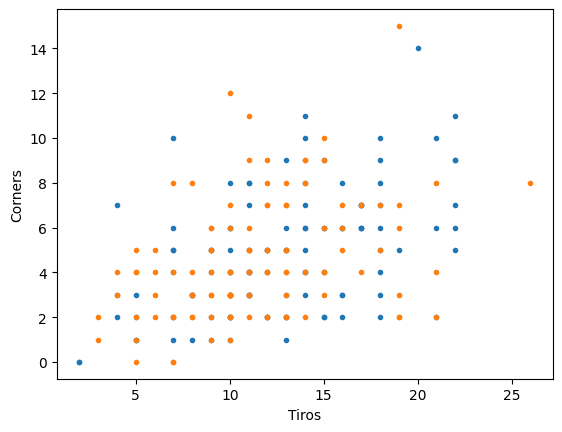

In [98]:
plt.plot(datos_2024.HS,datos_2024.HC,'.')
plt.plot(datos_2024.AS,datos_2024.AC,'.')
plt.ylabel('Corners')
plt.xlabel('Tiros')

In [99]:
datos_2024_en_casa_niza['nivel'] = datos_2024_en_casa_niza.apply(
    lambda row: devolver_categoria_partido(row['HomeTeam'], row['AwayTeam']),
    axis=1)

In [100]:
datos_2024_en_casa_niza[['HC','HS','nivel']].corr('pearson')

,HC,HS,nivel
HC,1.000000,-0.094995,-0.943242
HS,-0.094995,1.000000,0.415434
nivel,-0.943242,0.415434,1.000000


In [101]:
datos_2024_fuera_casa_niza = datos_2024_fuera_casa_niza[['Date','HomeTeam','AwayTeam','FTR','AC','AS','FTAG']]
datos_2024_fuera_casa_niza['nivel'] = datos_2024_fuera_casa_niza.apply(
    lambda row: devolver_categoria_partido(row['HomeTeam'], row['AwayTeam']),
    axis=1)

In [102]:
datos_2024_en_casa_niza

,HomeTeam,AwayTeam,FTR,HC,HS,FTHG,tiros/goles,tiros/corner,nivel
Date,,,,,,,,,
2024-09-20,Nice,St Etienne,H,3.0,18.0,8.0,44.4,6.000,3
2024-10-06,Nice,Paris SG,D,5.0,9.0,1.0,11.1,1.800,1
2024-10-27,Nice,Monaco,H,6.0,17.0,2.0,11.8,2.833,1
2024-11-10,Nice,Lille,D,6.0,17.0,2.0,11.8,2.833,1
2024-11-24,Nice,Strasbourg,H,4.0,15.0,2.0,13.3,3.750,2


In [103]:
datos_2024_fuera_casa_niza[['AC','AS','nivel']].corr('pearson')

,AC,AS,nivel
AC,1.000000,0.013722,0.884436
AS,0.013722,1.000000,0.114079
nivel,0.884436,0.114079,1.000000


In [104]:
fuera_oficial_niza = datos_2024_fuera_casa_niza[2:3]
fuera_oficial_niza

,Date,HomeTeam,AwayTeam,FTR,AC,AS,FTAG,nivel
28,14/09/2024,Marseille,Nice,H,2.0,12.0,0.0,1


con el niza obtenemos una correlacion muy alta entre el nivel del partido y el numero de corneres
tanto en casa como fuera, por lo que podemos filtrar los datos por nivel. Luego para el niza tenemos:

In [105]:
niza_oficial_casa = datos_2024_en_casa_niza[1:]
niza_oficial_casa = niza_oficial_casa[['HomeTeam','HC','HS','FTHG']].rename(columns = {'HomeTeam':'equipo',\
    'HC':'corner','HS':'tiros','FTHG':'goles'})
niza_oficial_fuera = fuera_oficial_niza[['AwayTeam','AC','AS','FTAG']].rename(columns = {'AwayTeam':'equipo',\
    'AC':'corner','AS':'tiros','FTAG':'goles'})

In [106]:
niza = pd.concat([niza_oficial_casa,niza_oficial_fuera])
niza[['corner','tiros','goles']].corr()
#refleja un correlacion muy alta entre goles y corneres esperados

,corner,tiros,goles
corner,1.000000,0.474420,0.801784
tiros,0.474420,1.000000,0.726184
goles,0.801784,0.726184,1.000000


In [107]:
# por tanto, mi predicción se puede basar en el número de goles esperado contra el lyon
# si espero 0 goles pondré entre 2 y 3 corneres, si espero 1 pondre entre 4 y 5, y si espero 2+ pondre 6
niza

,equipo,corner,tiros,goles
2024-10-06 00:00:00,Nice,5.0,9.0,1.0
2024-10-27 00:00:00,Nice,6.0,17.0,2.0
2024-11-10 00:00:00,Nice,6.0,17.0,2.0
2024-11-24 00:00:00,Nice,4.0,15.0,2.0
28,Nice,2.0,12.0,0.0


Para el Lyon:

In [108]:
lyon_casa = datos_2024_en_casa_Lyon[['Date','HomeTeam','AwayTeam','AC','AS','FTAG']]

In [109]:
lyon_casa['nivel'] = lyon_casa.apply(lambda row: devolver_categoria_partido(row['HomeTeam'], row['AwayTeam']),axis=1)

C:\Users\laura\AppData\Local\Temp\ipykernel_19188\581653604.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  lyon_casa['nivel'] = lyon_casa.apply(lambda row: devolver_categoria_partido(row['HomeTeam'], row['AwayTeam']),axis=1)


In [110]:
#datos extrapolables de corner recibidos en casa por parte del lyon, alto correlacion en nivel, y importante, el lyon en casa
# encaja mas con equipos de alto nivel, sin embargo los córneres recibidos son pocos
lyon_casa[['AC','AS','FTAG','nivel']].corr()

,AC,AS,FTAG,nivel
AC,1.000000,-0.116968,-0.914853,0.775315
AS,-0.116968,1.000000,0.047559,0.244257
FTAG,-0.914853,0.047559,1.000000,-0.906327
nivel,0.775315,0.244257,-0.906327,1.000000


In [111]:
lyon_casa = lyon_casa[1:2]

In [112]:
lyon_casa_oficial = lyon_casa[['HomeTeam','AC','AS','FTAG']].rename(columns = {'HomeTeam':'equipo',\
    'AC':'corner','AS':'tiros','FTAG':'goles'})

In [113]:
lyon_casa_oficial

,equipo,corner,tiros,goles
44,Lyon,3.0,6.0,3.0


In [114]:
fuera_lyon = datos_2024_fuera_casa_Lyon[['Date','HomeTeam','AwayTeam','HC','HS','FTHG']]
fuera_lyon['nivel'] = fuera_lyon.apply(lambda row: devolver_categoria_partido(row['HomeTeam'], row['AwayTeam']),
    axis=1)

C:\Users\laura\AppData\Local\Temp\ipykernel_19188\498699864.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  fuera_lyon['nivel'] = fuera_lyon.apply(lambda row: devolver_categoria_partido(row['HomeTeam'], row['AwayTeam']),


In [115]:
fuera_lyon[['HC','HS','FTHG','nivel']].corr('pearson')

,HC,HS,FTHG,nivel
HC,1.000000,0.814646,0.662266,0.481869
HS,0.814646,1.000000,0.899188,0.095957
FTHG,0.662266,0.899188,1.000000,0.242536
nivel,0.481869,0.095957,0.242536,1.000000


In [116]:
fuera_lyon = fuera_lyon[-1:]
fuera_lyon = fuera_lyon[['AwayTeam','HC','HS','FTHG']]
fuera_lyon = fuera_lyon.rename(columns= {'AwayTeam':'equipo',\
    'HC':'corner','HS':'tiros','FTHG':'goles'})

In [117]:
lyon = pd.concat([fuera_lyon,lyon_casa_oficial])

In [118]:
#lyon casa contra equipos grandes
lyon

,equipo,corner,tiros,goles
103,Lyon,4.0,14.0,1.0
44,Lyon,3.0,6.0,3.0


In [119]:
lyon.corner.mean()

np.float64(3.5)

In [120]:
niza.corner.mean()

np.float64(4.6)

In [121]:
#promedio corner niza fuera casa en nivel 1 y 2
(datos_2024_fuera_casa_niza.where(datos_2024_fuera_casa_niza['nivel']==2).dropna().AC.sum() + 2)/4

np.float64(3.25)

tras analizar todos los datos posibles:

Lyon y Niza se consideran como equipos grandes

Teniendo en cuenta que es un partido de primer nivel, que el niza juega fuera de casa donde promedia 4.66 c/p y que contra equipos de primer y segundo nivel, la media del nizia es de 3.25 c/p, mi predicción de corneres se encuentra entre 3 y 4.

Si nos vamos ahora a ver los que recibe el lyon, vemos que equipos grandes promedian entre 3 y 4. Por tanto, nos arriesgaremos un poco y elegiremos a la baja

## Finalmente, nuestra predicción son 3 corners favorables al Niza